<a href="https://colab.research.google.com/github/faizaan0619/MachineLearning/blob/main/Unsupervised/mall_customer_segmentation_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [17]:
df = pd.read_csv("/content/mall_customers.csv")

In [18]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


# **PREPROCESSING**

In [19]:
X = df[["Annual Income (k$)",	"Spending Score (1-100)"]]

In [20]:
X

,Annual Income (k$),Spending Score (1-100)
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0
...,...,...
995,133.3,1.0
996,82.6,40.0
997,67.7,26.0
998,45.7,59.0


In [21]:
X.isnull().sum()

,0
Annual Income (k$),4
Spending Score (1-100),6


In [22]:
X = X.fillna(X.mean())

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **TRAINING**

In [24]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

**ELBOW METHOD**

In [25]:
inertias = []
for k in range(2,9):
  kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
  kmeans.fit(X_scaled)
  inertias.append(kmeans.inertia_)

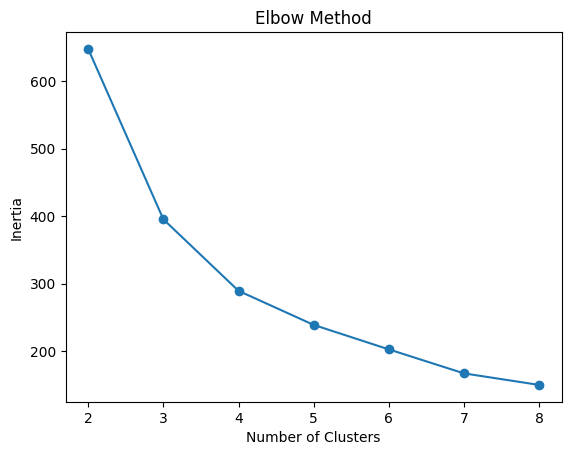

In [26]:
plt.plot(range(2,9), inertias, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [27]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

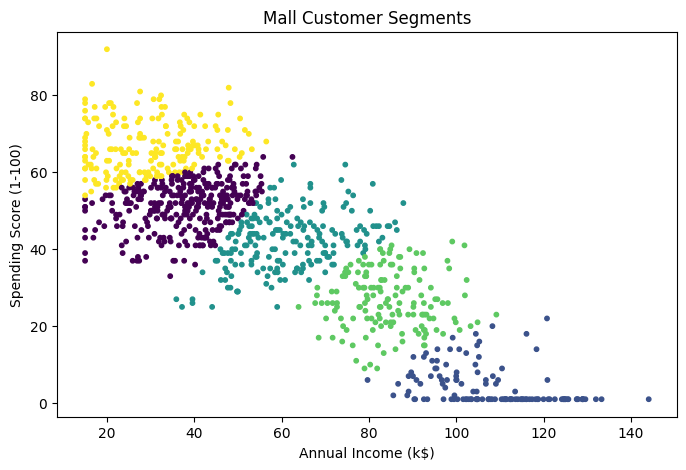

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=10
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customer Segments")

plt.show()

In [29]:
cluster_summary = df.groupby("Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean()

print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 37.889666               51.434251
1                107.915079                4.412698
2                 61.500510               42.174359
3                 84.565385               26.668790
4                 29.688889               66.687831


In [30]:
for cluster, row in cluster_summary.iterrows():

    income = row["Annual Income (k$)"]
    spending = row["Spending Score (1-100)"]

    if income >= 60 and spending >= 60:
        label = "VIP / Premium Customers"

    elif income >= 60 and spending < 40:
        label = "High-Income Low-Spenders"

    elif income < 40 and spending >= 60:
        label = "High-Spending Budget Customers"

    elif income < 40 and spending < 40:
        label = "Budget Customers"

    else:
        label = "Regular Customers"

    print(cluster, "→", label)

0 → Regular Customers
1 → High-Income Low-Spenders
2 → Regular Customers
3 → High-Income Low-Spenders
4 → High-Spending Budget Customers
